In [1]:
import xarray as xr
import dask.array as da
from dask.distributed import LocalCluster, Client, performance_report
import numpy as np
import psutil
import os
from dask.diagnostics import ProgressBar

# Auto-configure based on available cores
total_cores = psutil.cpu_count(logical=True)
n_workers = max(1, total_cores // 2)  # Conservative split
threads_per_worker = max(1, total_cores // n_workers)

cluster = LocalCluster(
    n_workers=n_workers,
    threads_per_worker=threads_per_worker,
    worker_dashboard_address=False,
    diagnostics_port=None  # Disable per-worker dashboards
)

client = Client(cluster)
client

my = "JANUARY_2022"

In [4]:
from openeo.local import LocalConnection

# Initialize the local connection
local_conn = LocalConnection("./")

# Define the STAC collection URL
stac_item = f"https://stac.intertwin.fedcloud.eu/collections/SINGLE_LEVELS_DAILY_SEAS5_{my}"

# Specify the spatial extent (bounding box)
# Specify the spatial extent (bounding box)
spatial_extent = {
    "west": 4,
    "east": 16,
    "south": 42,
    "north": 51
}

# Load the data cube with specified parameters
seas5_single = local_conn.load_stac(
    url=stac_item,
    spatial_extent=spatial_extent,
).execute().to_dataset(dim='bands')

# Display the dataset
stac_item = f"https://stac.intertwin.fedcloud.eu/collections/PRESSURE_LEVELS_DAILY_SEAS5_{my}"

from openeo.local import LocalConnection
local_conn = LocalConnection("./")

seas5_pressure = local_conn.load_stac(
    url=stac_item,
    spatial_extent=spatial_extent,
).execute().to_dataset(dim='bands')
 
SEAS5 = xr.merge([seas5_single, seas5_pressure]).drop_vars("pet")
SEAS5

<xarray.Dataset> Size: 879MB
Dimensions:  (time: 216, number: 51, y: 37, x: 49)
Coordinates:
  * number   (number) int32 204B 0 1 2 3 4 5 6 7 8 ... 43 44 45 46 47 48 49 50
  * time     (time) datetime64[ns] 2kB 2021-08-01 2021-08-02 ... 2022-03-04
  * x        (x) float32 196B 4.0 4.25 4.5 4.75 5.0 ... 15.25 15.5 15.75 16.0
  * y        (y) float32 148B 51.0 50.75 50.5 50.25 ... 42.75 42.5 42.25 42.0
Data variables:
    ssrd     (time, number, y, x) float64 160MB dask.array<chunksize=(216, 1, 37, 49), meta=np.ndarray>
    t2m      (time, number, y, x) float64 160MB dask.array<chunksize=(216, 1, 37, 49), meta=np.ndarray>
    tp       (time, number, y, x) float64 160MB dask.array<chunksize=(216, 1, 37, 49), meta=np.ndarray>
    q_850    (time, number, y, x) float32 80MB dask.array<chunksize=(216, 1, 37, 49), meta=np.ndarray>
    t_850    (time, number, y, x) float32 80MB dask.array<chunksize=(216, 1, 37, 49), meta=np.ndarray>
    u_850    (time, number, y, x) float32 80MB dask.array<chunksize=(216, 1, 37, 49), meta=np.ndarray>
    v_850    (time, number, y, x) float32 80MB dask.array<chunksize=(216, 1, 37, 49), meta=np.ndarray>
    z_850    (time, number, y, x) float32 80MB dask.array<chunksize=(216, 1, 37, 49), meta=np.ndarray>
Attributes:
    crs:      EPSG:4326

In [9]:
stac_item = "https://stac.intertwin.fedcloud.eu/collections/EMO1_DEM"

from openeo.local import LocalConnection
local_conn = LocalConnection("./")

dem = local_conn.load_stac(
    url=stac_item,
    spatial_extent=spatial_extent,
    bands=["dem"]
).execute()
dem = dem.to_dataset(dim='bands')["dem"].to_dataset()
dem = dem.isel(time=0)
dem = dem.drop_vars("time").rename({'lat': 'y', 'lon': 'x'})
dem

<xarray.Dataset> Size: 2MB
Dimensions:  (y: 540, x: 720)
Coordinates:
  * y        (y) float64 4kB 50.99 50.97 50.96 50.94 ... 42.06 42.04 42.02 42.01
  * x        (x) float64 6kB 4.008 4.025 4.042 4.058 ... 15.94 15.96 15.98 15.99
Data variables:
    dem      (y, x) float32 2MB dask.array<chunksize=(121, 421), meta=np.ndarray>

## REMAPPING

In [6]:
import xarray as xr
import numpy as np

def match_to_mid_resolution(source_ds, target_ds, lat_name='lat', lon_name='lon',
                            num_mid_lats=None, num_mid_lons=None):
    """
    Interpolates both source and target datasets to a common mid-resolution grid,
    then expands the target (e.g., DEM) to match source's non-spatial dimensions and aligns chunks.
    
    Parameters:
        source_ds: xarray.Dataset, multi-dimensional (e.g. time, lat, lon)
        target_ds: xarray.Dataset, typically with lat/lon only (e.g. DEM)
        lat_name: str, name of latitude coordinate
        lon_name: str, name of longitude coordinate
        num_mid_lats: int, number of mid-resolution latitudes (default: half of target's)
        num_mid_lons: int, number of mid-resolution longitudes (default: half of target's)

    Returns:
        Tuple of (interpolated source_ds, expanded/interpolated target_ds) with aligned chunks
    """
    # Default mid-resolution size
    if num_mid_lats is None:
        num_mid_lats = len(target_ds[lat_name]) // 3
    if num_mid_lons is None:
        num_mid_lons = len(target_ds[lon_name]) // 3

    # Find common lat/lon bounds
    min_lat = max(source_ds[lat_name].min().item(), target_ds[lat_name].min().item())
    max_lat = min(source_ds[lat_name].max().item(), target_ds[lat_name].max().item())
    min_lon = max(source_ds[lon_name].min().item(), target_ds[lon_name].min().item())
    max_lon = min(source_ds[lon_name].max().item(), target_ds[lon_name].max().item())

    # Mid-resolution coordinate arrays
    mid_lats = np.linspace(min_lat, max_lat, num_mid_lats)
    mid_lons = np.linspace(min_lon, max_lon, num_mid_lons)

    mid_coords = {
        lat_name: xr.DataArray(mid_lats, dims=lat_name),
        lon_name: xr.DataArray(mid_lons, dims=lon_name)
    }

    # Interpolate both datasets
    source_mid = source_ds.interp(mid_coords, method='linear')
    target_mid = target_ds.interp(mid_coords, method='linear')

    # Expand target to match source's additional dimensions (e.g., time, ensemble)
    extra_dims = {dim: source_mid.coords[dim] for dim in source_mid.dims
                  if dim not in [lat_name, lon_name]}

    if extra_dims:
        target_expanded = target_mid.expand_dims(extra_dims).broadcast_like(source_mid)
    else:
        target_expanded = target_mid

    # Align chunks if either is dask-backed
    source_mid, target_expanded = xr.align(source_mid, target_expanded)

    target_expanded = target_expanded.chunk(source_mid.chunks)

    returned = xr.merge([source_mid, target_expanded]).astype('float32')

    return returned

SEAS5_interpolated = match_to_mid_resolution(SEAS5, dem, "y", "x")
SEAS5_interpolated

<xarray.Dataset> Size: 34GB
Dimensions:  (time: 216, number: 51, y: 240, x: 360)
Coordinates:
  * number   (number) int32 204B 0 1 2 3 4 5 6 7 8 ... 43 44 45 46 47 48 49 50
  * time     (time) datetime64[ns] 2kB 2021-08-01 2021-08-02 ... 2022-03-04
  * y        (y) float64 2kB 42.0 42.04 42.08 42.11 ... 50.89 50.92 50.96 51.0
  * x        (x) float64 3kB 4.0 4.033 4.067 4.1 4.134 ... 15.9 15.93 15.97 16.0
Data variables:
    ssrd     (time, number, y, x) float32 4GB dask.array<chunksize=(216, 1, 240, 360), meta=np.ndarray>
    t2m      (time, number, y, x) float32 4GB dask.array<chunksize=(216, 1, 240, 360), meta=np.ndarray>
    tp       (time, number, y, x) float32 4GB dask.array<chunksize=(216, 1, 240, 360), meta=np.ndarray>
    q_850    (time, number, y, x) float32 4GB dask.array<chunksize=(216, 1, 240, 360), meta=np.ndarray>
    t_850    (time, number, y, x) float32 4GB dask.array<chunksize=(216, 1, 240, 360), meta=np.ndarray>
    u_850    (time, number, y, x) float32 4GB dask.array<chunksize=(216, 1, 240, 360), meta=np.ndarray>
    v_850    (time, number, y, x) float32 4GB dask.array<chunksize=(216, 1, 240, 360), meta=np.ndarray>
    z_850    (time, number, y, x) float32 4GB dask.array<chunksize=(216, 1, 240, 360), meta=np.ndarray>
    dem      (time, number, y, x) float32 4GB dask.array<chunksize=(216, 1, 240, 360), meta=np.ndarray>
Attributes:
    crs:      EPSG:4326

Cyclic Feature Addition

In [5]:
import numpy as np
import dask.array as da
from datetime import date


def encode_cyclical_features(values, max_value):
    """Encode cyclical features using sine and cosine transformations."""
    sin = np.sin(2 * np.pi * values / max_value)
    cos = np.cos(2 * np.pi * values / max_value)
    return sin, cos

def repeat_along_axis(arr, repeats, axis):
    """Repeat array along specified axis."""
    return da.repeat(arr[None, ...], repeats, axis=axis)

def get_spatial_dims(ds):
    """
    Detect spatial dimension names in the dataset.
    Returns (y_dim, x_dim) tuple based on common naming conventions.
    """
    dims = set(ds.dims)
    
    y_candidates = ['y', 'lat', 'latitude', 'lats']
    x_candidates = ['x', 'lon', 'longitude', 'long', 'lons']
    
    y_dim = next((d for d in y_candidates if d in dims), None)
    x_dim = next((d for d in x_candidates if d in dims), None)
    
    if y_dim is None or x_dim is None:
        raise ValueError(
            f"Could not detect spatial dimensions. Available dimensions: {list(dims)}. "
            f"Tried y names: {y_candidates}, x names: {x_candidates}"
        )
    
    return y_dim, x_dim

def get_existing_chunks(ds, dims):
    """
    Get chunking pattern from existing variables in the dataset.
    Returns dict of {dim: chunksize} for the specified dimensions.
    """
    chunks = {}
    for var in ds.data_vars.values():
        if hasattr(var.data, 'chunks'):
            var_chunks = dict(zip(var.dims, var.data.chunks))
            for dim in dims:
                if dim in var_chunks and dim not in chunks:
                    # Take first chunk size found for each dimension
                    chunks[dim] = var_chunks[dim][0]
        if all(dim in chunks for dim in dims):
            break
    return chunks or None

def encode_doys(ds, time_dim='time', spatial_dims=None, extra_dims=None, inplace=False):
    """
    Encode day of year as cyclical features and add to dataset, handling:
    - ERA5 (time, y, x)
    - SEAS5 (time, number, y, x) or similar
    
    Parameters:
    -----------
    ds : xarray.Dataset
        Input dataset containing time dimension
    time_dim : str, optional
        Name of time dimension (default: 'time')
    spatial_dims : tuple, optional
        Explicit (y_dim, x_dim) names. If None, auto-detect.
    extra_dims : list, optional
        Additional dimensions (e.g., ['number']) to repeat along
    inplace : bool, optional
        If True, modify dataset in place (default: False)
    
    Returns:
    --------
    xarray.Dataset
        Dataset with sin_doy and cos_doy variables added
    """
    if not inplace:
        ds = ds.copy()
    
    # Auto-detect spatial dims if not provided
    if spatial_dims is None:
        y_dim, x_dim = get_spatial_dims(ds)
    else:
        y_dim, x_dim = spatial_dims
    
    # Determine all target dimensions
    target_dims = [time_dim]
    if extra_dims:
        target_dims.extend(extra_dims)
    target_dims.extend([y_dim, x_dim])
    
    # Get chunking pattern from existing variables
    chunks = get_existing_chunks(ds, target_dims)
    
    # Compute day of year
    doys = ds[time_dim].values.astype('datetime64[D]')
    doys = da.asarray([date.timetuple(doy.astype(object)).tm_yday for doy in doys])
    
    # Encode cyclical features
    sin_doy, cos_doy = encode_cyclical_features(doys, 365)
    
    # Reshape and repeat along all non-time dimensions
    for dim in target_dims[1:]:  # Skip time_dim
        repeats = len(ds[dim])
        sin_doy = da.repeat(sin_doy[..., None], repeats, axis=-1)
        cos_doy = da.repeat(cos_doy[..., None], repeats, axis=-1)
    
    # Reshape to final dimensions
    sin_doy = sin_doy.reshape([len(ds[dim]) for dim in target_dims])
    cos_doy = cos_doy.reshape([len(ds[dim]) for dim in target_dims])
    
    # Apply chunking if found
    if chunks:
        chunk_sizes = [chunks.get(dim, -1) for dim in target_dims]
        sin_doy = sin_doy.rechunk(chunk_sizes)
        cos_doy = cos_doy.rechunk(chunk_sizes)
    
    # Add to dataset
    ds['sin_doy'] = (target_dims, sin_doy)
    ds['cos_doy'] = (target_dims, cos_doy)
    
    # Add attributes
    for name in ['sin_doy', 'cos_doy']:
        ds[name].attrs.update({
            'long_name': f"{'Sine' if 'sin' in name else 'Cosine'} of day of year",
            'units': 'unitless',
            'description': f"Cyclical encoding of day of year"
        })
    
    return ds

    # For ERA5 (only time, y, x)
encode_doys(SEAS5_interpolated, inplace=True)

SEAS5_interpolated = SEAS5_interpolated.chunk({"time": 216, "y": 180, "x": 240, "number": 1})

SEAS5_interpolated.to_zarr(f"/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/SEAS5_to_latent_{my}.zarr", compute=True, mode="w")

<xarray.Dataset> Size: 157GB
Dimensions:  (lat: 721, lon: 1081, time: 8401)
Coordinates:
  * lat      (lat) float64 6kB 51.99 51.97 51.96 51.94 ... 40.02 40.01 39.99
  * lon      (lon) float64 9kB 2.008 2.025 2.042 2.058 ... 19.98 19.99 20.01
  * time     (time) datetime64[ns] 67kB 2000-01-01 2000-01-02 ... 2022-12-31
Data variables:
    pet      (time, lat, lon) float32 26GB dask.array<chunksize=(365, 64, 64), meta=np.ndarray>
    pr       (time, lat, lon) float64 52GB dask.array<chunksize=(365, 64, 64), meta=np.ndarray>
    rg       (time, lat, lon) float64 52GB dask.array<chunksize=(365, 64, 64), meta=np.ndarray>
    ta24     (time, lat, lon) float32 26GB dask.array<chunksize=(365, 64, 64), meta=np.ndarray>
Attributes: (12/19)
    CDI:                       Climate Data Interface version 2.4.0 (https://...
    CDO:                       Climate Data Operators version 2.4.0 (https://...
    Conventions:               CF-1.6
    NCO:                       netCDF Operators version 5.1.9 (Homepage = htt...
    PET_Calculation:           Jensen-Haise method - using pyet python packga...
    Source_Software:           SPHEREMAP for EFAS SC9 (c) DWD-GPCC (08 March ...
    ...                        ...
    institution:               European Commission - Disaster Risk Management...
    keywords:                  Lisflood, Europe
    preprocessing_steps:       Assigned CRS as EPSG:4326 and clipped the data...
    reference:                 A European daily high-resolution gridded meteo...
    source:                    Lisflood Europe meteo maps - pb2015
    title:                     Lisflood meteo maps 1990-2021 for European set...

In [4]:
import xarray as xr
import numpy as np

def match_to_mid_resolution(source_ds, target_ds, lat_name='lat', lon_name='lon',
                            num_mid_lats=None, num_mid_lons=None):
    """
    Interpolates both source and target datasets to a common mid-resolution grid,
    then expands the target (e.g., DEM) to match source's non-spatial dimensions and aligns chunks.
    
    Parameters:
        source_ds: xarray.Dataset, multi-dimensional (e.g. time, lat, lon)
        target_ds: xarray.Dataset, typically with lat/lon only (e.g. DEM)
        lat_name: str, name of latitude coordinate
        lon_name: str, name of longitude coordinate
        num_mid_lats: int, number of mid-resolution latitudes (default: half of target's)
        num_mid_lons: int, number of mid-resolution longitudes (default: half of target's)

    Returns:
        Tuple of (interpolated source_ds, expanded/interpolated target_ds) with aligned chunks
    """
    # Default mid-resolution size
    if num_mid_lats is None:
        num_mid_lats = len(target_ds[lat_name]) // 3
    if num_mid_lons is None:
        num_mid_lons = len(target_ds[lon_name]) // 3

    # Find common lat/lon bounds
    min_lat = max(source_ds[lat_name].min().item(), target_ds[lat_name].min().item())
    max_lat = min(source_ds[lat_name].max().item(), target_ds[lat_name].max().item())
    min_lon = max(source_ds[lon_name].min().item(), target_ds[lon_name].min().item())
    max_lon = min(source_ds[lon_name].max().item(), target_ds[lon_name].max().item())

    # Mid-resolution coordinate arrays
    mid_lats = np.linspace(min_lat, max_lat, num_mid_lats)
    mid_lons = np.linspace(min_lon, max_lon, num_mid_lons)

    mid_coords = {
        lat_name: xr.DataArray(mid_lats, dims=lat_name),
        lon_name: xr.DataArray(mid_lons, dims=lon_name)
    }

    # Interpolate both datasets
    source_mid = source_ds.interp(mid_coords, method='linear')
    target_mid = target_ds.interp(mid_coords, method='linear')

    # Expand target to match source's additional dimensions (e.g., time, ensemble)
    extra_dims = {dim: source_mid.coords[dim] for dim in source_mid.dims
                  if dim not in [lat_name, lon_name]}

    if extra_dims:
        target_expanded = target_mid.expand_dims(extra_dims).broadcast_like(source_mid)
    else:
        target_expanded = target_mid

    # Align chunks if either is dask-backed
    source_mid, target_expanded = xr.align(source_mid, target_expanded)

    target_expanded = target_expanded.chunk(source_mid.chunks)

    returned = xr.merge([source_mid, target_expanded]).astype('float32')

    return returned

emo1_mid = match_to_mid_resolution(ds, dem, "y", "x")
emo1_mid = emo1_mid.compute()


/home/sdhinakaran/micromamba/envs/zarr_downScaleML/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 32.18 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [5]:
emo1_mid = emo1_mid.rename({"y": "lat", "x": "lon"})


In [30]:
emo1_mid = emo1_mid.drop_vars("dem")


<xarray.Dataset> Size: 10GB
Dimensions:  (time: 8401, lat: 180, lon: 270)
Coordinates:
  * time     (time) datetime64[ns] 67kB 2000-01-01 2000-01-02 ... 2022-12-31
  * lat      (lat) float64 1kB 39.99 40.06 40.13 40.19 ... 51.86 51.92 51.99
  * lon      (lon) float64 2kB 2.008 2.075 2.142 2.209 ... 19.87 19.94 20.01
Data variables:
    pet      (time, lat, lon) float64 3GB nan nan nan ... 0.2609 0.2584 0.2551
    pr       (time, lat, lon) float32 2GB nan nan nan nan ... 0.0 0.0 0.0 0.0
    rg       (time, lat, lon) float32 2GB nan nan nan ... 1.98e+06 1.95e+06
    ta24     (time, lat, lon) float64 3GB nan nan nan nan ... 9.865 9.933 9.967
Attributes: (12/19)
    CDI:                       Climate Data Interface version 2.4.0 (https://...
    CDO:                       Climate Data Operators version 2.4.0 (https://...
    Conventions:               CF-1.6
    NCO:                       netCDF Operators version 5.1.9 (Homepage = htt...
    PET_Calculation:           Jensen-Haise method - using pyet python packga...
    Source_Software:           SPHEREMAP for EFAS SC9 (c) DWD-GPCC (08 March ...
    ...                        ...
    institution:               European Commission - Disaster Risk Management...
    keywords:                  Lisflood, Europe
    preprocessing_steps:       Assigned CRS as EPSG:4326 and clipped the data...
    reference:                 A European daily high-resolution gridded meteo...
    source:                    Lisflood Europe meteo maps - pb2015
    title:                     Lisflood meteo maps 1990-2021 for European set...

In [1]:
import xarray as xr
ds = xr.open_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/data/EMO1_PROCESSED_2000_2022_ta24_pr_rg_pet_daily.zarr/")
ds = ds.rename({"ta24": "t2m", "pr": "tp", "rg": "ssrd"})
ds["t2m"] = ds["t2m"] + 273.15

zarr_path = "/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/stage2/y/y_stage2.zarr"

# Loop through each variable and save it one by one
for i, var_name in enumerate(ds.data_vars):
    print(f"Processing variable {i+1}/{len(ds.data_vars)}: {var_name}")
    
    # Select only the current variable
    var_ds = ds[[var_name]]
    
    # Write to Zarr (use 'w' mode for the first variable, 'a' for subsequent ones)
    mode = "w" if i == 0 else "a"
    var_ds.to_zarr(zarr_path, mode=mode, compute=True)

print("All variables saved successfully!")

Processing variable 1/4: pet
Processing variable 2/4: tp
Processing variable 3/4: ssrd
Processing variable 4/4: t2m
All variables saved successfully!


In [12]:
emo1_mid.to_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/EMO1_STAGE1_2000_2022_t2m_tp_ssrd_pet_by_3.zarr")

In [10]:
emo1_mid = emo1_mid.drop_vars("dem")

In [11]:
emo1_mid

<xarray.Dataset> Size: 17GB
Dimensions:  (time: 8401, lat: 240, lon: 360)
Coordinates:
  * time     (time) datetime64[ns] 67kB 2000-01-01 2000-01-02 ... 2022-12-31
  * lat      (lat) float64 2kB 39.99 40.04 40.09 40.14 ... 51.89 51.94 51.99
  * lon      (lon) float64 3kB 2.008 2.058 2.109 2.159 ... 19.91 19.96 20.01
Data variables:
    pet      (time, lat, lon) float64 6GB nan nan nan ... 0.261 0.2591 0.2551
    tp       (time, lat, lon) float32 3GB nan nan nan nan ... 0.0 0.0 0.0 0.0
    ssrd     (time, lat, lon) float32 3GB nan nan nan ... 1.98e+06 1.95e+06
    t2m      (time, lat, lon) float64 6GB nan nan nan nan ... 283.1 283.1 283.1
Attributes: (12/19)
    CDI:                       Climate Data Interface version 2.4.0 (https://...
    CDO:                       Climate Data Operators version 2.4.0 (https://...
    Conventions:               CF-1.6
    NCO:                       netCDF Operators version 5.1.9 (Homepage = htt...
    PET_Calculation:           Jensen-Haise method - using pyet python packga...
    Source_Software:           SPHEREMAP for EFAS SC9 (c) DWD-GPCC (08 March ...
    ...                        ...
    institution:               European Commission - Disaster Risk Management...
    keywords:                  Lisflood, Europe
    preprocessing_steps:       Assigned CRS as EPSG:4326 and clipped the data...
    reference:                 A European daily high-resolution gridded meteo...
    source:                    Lisflood Europe meteo maps - pb2015
    title:                     Lisflood meteo maps 1990-2021 for European set...

In [8]:
import xarray as xr
import dask.array as da
from dask.distributed import LocalCluster, Client, performance_report
import numpy as np
import psutil
import os
from dask.diagnostics import ProgressBar
from datetime import date
from openeo.local import LocalConnection

# Auto-configure based on available cores
total_cores = psutil.cpu_count(logical=True)
n_workers = max(1, total_cores // 2)  # Conservative split
threads_per_worker = max(1, total_cores // n_workers)

cluster = LocalCluster(
    n_workers=n_workers,
    threads_per_worker=threads_per_worker,
    worker_dashboard_address=False,
    diagnostics_port=None  # Disable per-worker dashboards
)

client = Client(cluster)
client

my = ["AUGUST_2021", "SEPTEMBER_2021", "OCTOBER_2021", "NOVEMBER_2021", 
      "DECEMBER_2021", "JANUARY_2022", "FEBRAURY_2022", "MARCH_2022", 
      "APRIL_2022", "MAY_2022", "JUNE_2022", "JULY_2022"]


# Initialize the local connection
local_conn = LocalConnection("./")

# Define the spatial extent (bounding box)
spatial_extent = {
    "west": 4,
    "east": 16,
    "south": 42,
    "north": 51
}

# Load DEM data (only needs to be done once)
stac_item = "https://stac.intertwin.fedcloud.eu/collections/EMO1_DEM"
dem = local_conn.load_stac(
    url=stac_item,
    spatial_extent=spatial_extent,
    bands=["dem"]
).execute()
dem = dem.to_dataset(dim='bands')["dem"].to_dataset()
dem = dem.isel(time=0)
dem = dem.drop_vars("time").rename({'lat': 'y', 'lon': 'x'})

def match_to_mid_resolution(source_ds, target_ds, lat_name='lat', lon_name='lon',
                          num_mid_lats=None, num_mid_lons=None):
    """
    Interpolates both source and target datasets to a common mid-resolution grid,
    then expands the target (e.g., DEM) to match source's non-spatial dimensions and aligns chunks.
    
    Uses //3 division for mid-resolution calculation as originally intended.
    """
    # Default mid-resolution size - now using //3 as originally designed
    if num_mid_lats is None:
        num_mid_lats = len(target_ds[lat_name]) // 3  # Changed from //2 to //3
    if num_mid_lons is None:
        num_mid_lons = len(target_ds[lon_name]) // 3  # Changed from //2 to //3

    # Find common lat/lon bounds
    min_lat = max(source_ds[lat_name].min().item(), target_ds[lat_name].min().item())
    max_lat = min(source_ds[lat_name].max().item(), target_ds[lat_name].max().item())
    min_lon = max(source_ds[lon_name].min().item(), target_ds[lon_name].min().item())
    max_lon = min(source_ds[lon_name].max().item(), target_ds[lon_name].max().item())

    # Mid-resolution coordinate arrays
    mid_lats = np.linspace(min_lat, max_lat, num_mid_lats)
    mid_lons = np.linspace(min_lon, max_lon, num_mid_lons)

    mid_coords = {
        lat_name: xr.DataArray(mid_lats, dims=lat_name),
        lon_name: xr.DataArray(mid_lons, dims=lon_name)
    }

    # Interpolate both datasets
    source_mid = source_ds.interp(mid_coords, method='linear')
    target_mid = target_ds.interp(mid_coords, method='linear')

    # Expand target to match source's additional dimensions (e.g., time, ensemble)
    extra_dims = {dim: source_mid.coords[dim] for dim in source_mid.dims
                 if dim not in [lat_name, lon_name]}

    if extra_dims:
        target_expanded = target_mid.expand_dims(extra_dims).broadcast_like(source_mid)
    else:
        target_expanded = target_mid

    # Align chunks if either is dask-backed
    source_mid, target_expanded = xr.align(source_mid, target_expanded)
    target_expanded = target_expanded.chunk(source_mid.chunks)

    returned = xr.merge([source_mid, target_expanded]).astype('float32')
    return returned

def encode_cyclical_features(values, max_value):
    """Encode cyclical features using sine and cosine transformations."""
    sin = np.sin(2 * np.pi * values / max_value)
    cos = np.cos(2 * np.pi * values / max_value)
    return sin, cos

def get_spatial_dims(ds):
    """Detect spatial dimension names in the dataset."""
    dims = set(ds.dims)
    
    y_candidates = ['y', 'lat', 'latitude', 'lats']
    x_candidates = ['x', 'lon', 'longitude', 'long', 'lons']
    
    y_dim = next((d for d in y_candidates if d in dims), None)
    x_dim = next((d for d in x_candidates if d in dims), None)
    
    if y_dim is None or x_dim is None:
        raise ValueError(
            f"Could not detect spatial dimensions. Available dimensions: {list(dims)}. "
            f"Tried y names: {y_candidates}, x names: {x_candidates}"
        )
    
    return y_dim, x_dim

def get_existing_chunks(ds, dims):
    """Get chunking pattern from existing variables in the dataset."""
    chunks = {}
    for var in ds.data_vars.values():
        if hasattr(var.data, 'chunks'):
            var_chunks = dict(zip(var.dims, var.data.chunks))
            for dim in dims:
                if dim in var_chunks and dim not in chunks:
                    chunks[dim] = var_chunks[dim][0]
        if all(dim in chunks for dim in dims):
            break
    return chunks or None

def encode_doys(ds, time_dim='time', spatial_dims=None, extra_dims=None, inplace=False):
    """Encode day of year as cyclical features and add to dataset."""
    if not inplace:
        ds = ds.copy()
    
    # Auto-detect spatial dims if not provided
    if spatial_dims is None:
        y_dim, x_dim = get_spatial_dims(ds)
    else:
        y_dim, x_dim = spatial_dims
    
    # Determine all target dimensions
    target_dims = [time_dim]
    if extra_dims:
        target_dims.extend(extra_dims)
    target_dims.extend([y_dim, x_dim])
    
    # Get chunking pattern from existing variables
    chunks = get_existing_chunks(ds, target_dims)
    
    # Compute day of year
    doys = ds[time_dim].values.astype('datetime64[D]')
    doys = da.asarray([date.timetuple(doy.astype(object)).tm_yday for doy in doys])
    
    # Encode cyclical features
    sin_doy, cos_doy = encode_cyclical_features(doys, 365)
    
    # Reshape and repeat along all non-time dimensions
    for dim in target_dims[1:]:  # Skip time_dim
        repeats = len(ds[dim])
        sin_doy = da.repeat(sin_doy[..., None], repeats, axis=-1)
        cos_doy = da.repeat(cos_doy[..., None], repeats, axis=-1)
    
    # Reshape to final dimensions
    sin_doy = sin_doy.reshape([len(ds[dim]) for dim in target_dims])
    cos_doy = cos_doy.reshape([len(ds[dim]) for dim in target_dims])
    
    # Apply chunking if found
    if chunks:
        chunk_sizes = [chunks.get(dim, -1) for dim in target_dims]
        sin_doy = sin_doy.rechunk(chunk_sizes)
        cos_doy = cos_doy.rechunk(chunk_sizes)
    
    # Add to dataset
    ds['sin_doy'] = (target_dims, sin_doy)
    ds['cos_doy'] = (target_dims, cos_doy)
    
    # Add attributes
    for name in ['sin_doy', 'cos_doy']:
        ds[name].attrs.update({
            'long_name': f"{'Sine' if 'sin' in name else 'Cosine'} of day of year",
            'units': 'unitless',
            'description': f"Cyclical encoding of day of year"
        })
    
    return ds

# Process each month in the list
for month in my:
    print(f"\nProcessing {month}...")
    
    # Load single level data
    stac_item = f"https://stac.intertwin.fedcloud.eu/collections/SINGLE_LEVELS_DAILY_SEAS5_{month}"
    seas5_single = local_conn.load_stac(
        url=stac_item,
        spatial_extent=spatial_extent,
    ).execute().to_dataset(dim='bands')
    
    # Load pressure level data
    stac_item = f"https://stac.intertwin.fedcloud.eu/collections/PRESSURE_LEVELS_DAILY_SEAS5_{month}"
    seas5_pressure = local_conn.load_stac(
        url=stac_item,
        spatial_extent=spatial_extent,
    ).execute().to_dataset(dim='bands')
    
    # Merge and clean
    SEAS5 = xr.merge([seas5_single, seas5_pressure]).drop_vars("pet")
    
    # Interpolate to match DEM resolution
    SEAS5_interpolated = match_to_mid_resolution(SEAS5, dem, "y", "x")
    
    # Encode day of year
    encode_doys(SEAS5_interpolated, inplace=True)
    
    # Rechunk
    SEAS5_interpolated = SEAS5_interpolated.chunk({"time": 216, "y": 180, "x": 240, "number": 1})
    
    # Save to Zarr
    zarr_path = f"/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/v3/SEAS5/SEAS5_to_latent_{month}.zarr"
    
    # Loop through each variable and save it one by one
    for i, var_name in enumerate(SEAS5_interpolated.data_vars):
        print(f"  Saving variable {i+1}/{len(SEAS5_interpolated.data_vars)}: {var_name}")
        
        # Select only the current variable
        var_ds = SEAS5_interpolated[[var_name]]
        
        # Write to Zarr (use 'w' mode for the first variable, 'a' for subsequent ones)
        mode = "w" if i == 0 else "a"
        var_ds.to_zarr(zarr_path, mode=mode, compute=True)
    
    print(f"Completed processing {month}")

print("\nAll months processed successfully!")

/home/sdhinakaran/micromamba/envs/zarr_downScaleML/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41049 instead
  warnings.warn(



Processing AUGUST_2021...
  Saving variable 1/11: ssrd
  Saving variable 2/11: t2m
  Saving variable 3/11: tp
  Saving variable 4/11: q_850
  Saving variable 5/11: t_850
  Saving variable 6/11: u_850
  Saving variable 7/11: v_850
  Saving variable 8/11: z_850
  Saving variable 9/11: dem
  Saving variable 10/11: sin_doy
  Saving variable 11/11: cos_doy
Completed processing AUGUST_2021

Processing SEPTEMBER_2021...
  Saving variable 1/11: ssrd
  Saving variable 2/11: t2m
  Saving variable 3/11: tp
  Saving variable 4/11: q_850
  Saving variable 5/11: t_850
  Saving variable 6/11: u_850
  Saving variable 7/11: v_850
  Saving variable 8/11: z_850
  Saving variable 9/11: dem
  Saving variable 10/11: sin_doy
  Saving variable 11/11: cos_doy
Completed processing SEPTEMBER_2021

Processing OCTOBER_2021...
  Saving variable 1/11: ssrd
  Saving variable 2/11: t2m
  Saving variable 3/11: tp
  Saving variable 4/11: q_850
  Saving variable 5/11: t_850
  Saving variable 6/11: u_850
  Saving variabl

In [9]:
import xarray as xr

ds = xr.open_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/v3/SEAS5/SEAS5_to_latent_AUGUST_2021.zarr")
ds

<xarray.Dataset> Size: 17GB
Dimensions:  (time: 216, y: 180, x: 240, number: 51)
Coordinates:
  * number   (number) int32 204B 0 1 2 3 4 5 6 7 8 ... 43 44 45 46 47 48 49 50
  * time     (time) datetime64[ns] 2kB 2021-08-01 2021-08-02 ... 2022-03-04
  * x        (x) float64 2kB 4.008 4.058 4.109 4.159 ... 15.84 15.89 15.94 15.99
  * y        (y) float64 1kB 42.01 42.06 42.11 42.16 ... 50.84 50.89 50.94 50.99
Data variables:
    cos_doy  (time, y, x) float64 75MB dask.array<chunksize=(216, 180, 240), meta=np.ndarray>
    dem      (time, number, y, x) float32 2GB dask.array<chunksize=(216, 1, 180, 240), meta=np.ndarray>
    q_850    (time, number, y, x) float32 2GB dask.array<chunksize=(216, 1, 180, 240), meta=np.ndarray>
    sin_doy  (time, y, x) float64 75MB dask.array<chunksize=(216, 180, 240), meta=np.ndarray>
    ssrd     (time, number, y, x) float32 2GB dask.array<chunksize=(216, 1, 180, 240), meta=np.ndarray>
    t2m      (time, number, y, x) float32 2GB dask.array<chunksize=(216, 1, 180, 240), meta=np.ndarray>
    t_850    (time, number, y, x) float32 2GB dask.array<chunksize=(216, 1, 180, 240), meta=np.ndarray>
    tp       (time, number, y, x) float32 2GB dask.array<chunksize=(216, 1, 180, 240), meta=np.ndarray>
    u_850    (time, number, y, x) float32 2GB dask.array<chunksize=(216, 1, 180, 240), meta=np.ndarray>
    v_850    (time, number, y, x) float32 2GB dask.array<chunksize=(216, 1, 180, 240), meta=np.ndarray>
    z_850    (time, number, y, x) float32 2GB dask.array<chunksize=(216, 1, 180, 240), meta=np.ndarray>
Attributes:
    crs:      EPSG:4326

In [10]:
import xarray as xr

ds = xr.open_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/v3/ERA5_to_latent_by_3.zarr")
ds

<xarray.Dataset> Size: 17GB
Dimensions:  (time: 7670, lat: 180, lon: 240)
Coordinates:
  * lat      (lat) float64 1kB 42.01 42.06 42.11 42.16 ... 50.89 50.94 50.99
  * lon      (lon) float64 2kB 4.008 4.058 4.109 4.159 ... 15.89 15.94 15.99
  * time     (time) datetime64[ns] 61kB 2000-01-01 2000-01-02 ... 2020-12-30
Data variables:
    cos_doy  (time, lat, lon) float64 3GB dask.array<chunksize=(1000, 50, 50), meta=np.ndarray>
    dem      (time, lat, lon) float32 1GB dask.array<chunksize=(1000, 50, 50), meta=np.ndarray>
    q_850    (time, lat, lon) float32 1GB dask.array<chunksize=(1000, 50, 50), meta=np.ndarray>
    sin_doy  (time, lat, lon) float64 3GB dask.array<chunksize=(1000, 50, 50), meta=np.ndarray>
    ssrd     (time, lat, lon) float32 1GB dask.array<chunksize=(1000, 50, 50), meta=np.ndarray>
    t2m      (time, lat, lon) float32 1GB dask.array<chunksize=(1000, 50, 50), meta=np.ndarray>
    t_850    (time, lat, lon) float32 1GB dask.array<chunksize=(1000, 50, 50), meta=np.ndarray>
    tp       (time, lat, lon) float32 1GB dask.array<chunksize=(1000, 50, 50), meta=np.ndarray>
    u_850    (time, lat, lon) float32 1GB dask.array<chunksize=(1000, 50, 50), meta=np.ndarray>
    v_850    (time, lat, lon) float32 1GB dask.array<chunksize=(1000, 50, 50), meta=np.ndarray>
    z_850    (time, lat, lon) float32 1GB dask.array<chunksize=(1000, 50, 50), meta=np.ndarray>
Attributes:
    crs:      EPSG:4326

In [12]:
from openeo.local import LocalConnection

# Initialize the local connection
local_conn = LocalConnection("./")

# Define the STAC collection URL
stac_item = "https://stac.intertwin.fedcloud.eu/collections/SINGLE_LEVELS_DAILY_SEAS5_JANUARY_2022"

# Define spatial extent
spatial_extent = {
    "west": 4,
    "east": 16,
    "south": 42,
    "north": 51
}

# Load the STAC collection as a datacube
seas5_cube = local_conn.load_stac(
    url=stac_item,
    spatial_extent=spatial_extent,
)

# Filter by band (label), e.g., select '2m_temperature'
seas5_cube = seas5_cube.filter_labels(
    condition=lambda label: label == "t2m",
    dimension="number"
)

# Execute and convert to xarray datasetseas5_cube
seas5_cube = seas5_cube.execute()

ProcessParameterMissing: Error: Process Parameter value was missing for process eq

In [2]:
from openeo.local import LocalConnection

# Initialize the local connection
local_conn = LocalConnection("./")

# Define the STAC collection URL
stac_item = f"https://stac.intertwin.fedcloud.eu/collections/SINGLE_LEVELS_DAILY_SEAS5_JANUARY_2022"

# Specify the spatial extent (bounding box)
# Specify the spatial extent (bounding box)
spatial_extent = {
    "west": 4,
    "east": 16,
    "south": 42,
    "north": 51
}

# Load the data cube with specified parameters
seas5_single = local_conn.load_stac(
    url=stac_item,
    spatial_extent=spatial_extent,
).execute().to_dataset(dim='bands')

seas5_single

<xarray.Dataset> Size: 639MB
Dimensions:  (time: 216, number: 51, y: 37, x: 49)
Coordinates:
  * number   (number) int32 204B 0 1 2 3 4 5 6 7 8 ... 43 44 45 46 47 48 49 50
  * time     (time) datetime64[ns] 2kB 2022-01-01 2022-01-02 ... 2022-08-04
  * x        (x) float32 196B 4.0 4.25 4.5 4.75 5.0 ... 15.25 15.5 15.75 16.0
  * y        (y) float32 148B 51.0 50.75 50.5 50.25 ... 42.75 42.5 42.25 42.0
Data variables:
    pet      (time, number, y, x) float64 160MB dask.array<chunksize=(216, 1, 37, 49), meta=np.ndarray>
    ssrd     (time, number, y, x) float64 160MB dask.array<chunksize=(216, 1, 37, 49), meta=np.ndarray>
    t2m      (time, number, y, x) float64 160MB dask.array<chunksize=(216, 1, 37, 49), meta=np.ndarray>
    tp       (time, number, y, x) float64 160MB dask.array<chunksize=(216, 1, 37, 49), meta=np.ndarray>
Attributes:
    crs:      EPSG:4326

In [3]:
seas5_single["ssrd"] = seas5_single["ssrd"] * 86400


In [4]:
seas5_single

<xarray.Dataset> Size: 639MB
Dimensions:  (time: 216, number: 51, y: 37, x: 49)
Coordinates:
  * number   (number) int32 204B 0 1 2 3 4 5 6 7 8 ... 43 44 45 46 47 48 49 50
  * time     (time) datetime64[ns] 2kB 2022-01-01 2022-01-02 ... 2022-08-04
  * x        (x) float32 196B 4.0 4.25 4.5 4.75 5.0 ... 15.25 15.5 15.75 16.0
  * y        (y) float32 148B 51.0 50.75 50.5 50.25 ... 42.75 42.5 42.25 42.0
Data variables:
    pet      (time, number, y, x) float64 160MB dask.array<chunksize=(216, 1, 37, 49), meta=np.ndarray>
    ssrd     (time, number, y, x) float64 160MB dask.array<chunksize=(216, 1, 37, 49), meta=np.ndarray>
    t2m      (time, number, y, x) float64 160MB dask.array<chunksize=(216, 1, 37, 49), meta=np.ndarray>
    tp       (time, number, y, x) float64 160MB dask.array<chunksize=(216, 1, 37, 49), meta=np.ndarray>
Attributes:
    crs:      EPSG:4326

(array([   254.,   2303.,  10893.,  30670.,  47267.,  56525.,  83072.,
        101123.,  48948.,  10553.]),
 array([250.13441219, 255.19546996, 260.25652773, 265.31758549,
        270.37864326, 275.43970103, 280.5007588 , 285.56181657,
        290.62287434, 295.68393211, 300.74498988]),
 <BarContainer object of 10 artists>)

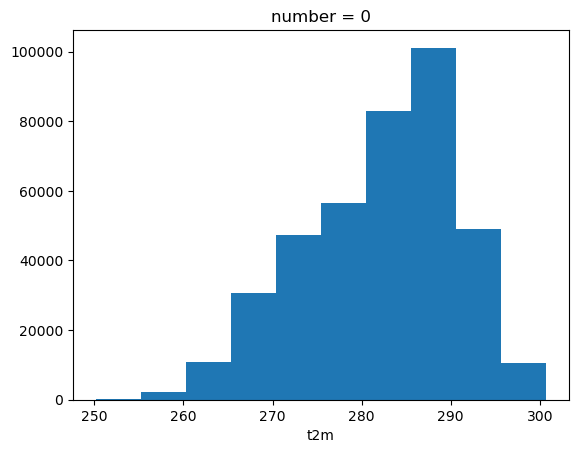

In [8]:
seas5_single

In [10]:
import xarray as xr
import numpy as np

def match_to_mid_resolution(source_ds, target_ds, lat_name='lat', lon_name='lon',
                            num_mid_lats=None, num_mid_lons=None):
    """
    Interpolates both source and target datasets to a common mid-resolution grid,
    then expands the target (e.g., DEM) to match source's non-spatial dimensions and aligns chunks.
    
    Parameters:
        source_ds: xarray.Dataset, multi-dimensional (e.g. time, lat, lon)
        target_ds: xarray.Dataset, typically with lat/lon only (e.g. DEM)
        lat_name: str, name of latitude coordinate
        lon_name: str, name of longitude coordinate
        num_mid_lats: int, number of mid-resolution latitudes (default: half of target's)
        num_mid_lons: int, number of mid-resolution longitudes (default: half of target's)

    Returns:
        Tuple of (interpolated source_ds, expanded/interpolated target_ds) with aligned chunks
    """
    # Default mid-resolution size
    if num_mid_lats is None:
        num_mid_lats = len(target_ds[lat_name])
    if num_mid_lons is None:
        num_mid_lons = len(target_ds[lon_name])

    # Find common lat/lon bounds
    min_lat = max(source_ds[lat_name].min().item(), target_ds[lat_name].min().item())
    max_lat = min(source_ds[lat_name].max().item(), target_ds[lat_name].max().item())
    min_lon = max(source_ds[lon_name].min().item(), target_ds[lon_name].min().item())
    max_lon = min(source_ds[lon_name].max().item(), target_ds[lon_name].max().item())

    # Mid-resolution coordinate arrays
    mid_lats = np.linspace(min_lat, max_lat, num_mid_lats)
    mid_lons = np.linspace(min_lon, max_lon, num_mid_lons)

    mid_coords = {
        lat_name: xr.DataArray(mid_lats, dims=lat_name),
        lon_name: xr.DataArray(mid_lons, dims=lon_name)
    }

    # Interpolate both datasets
    source_mid = source_ds.interp(mid_coords, method='linear')
    target_mid = target_ds.interp(mid_coords, method='linear')

    # Expand target to match source's additional dimensions (e.g., time, ensemble)
    extra_dims = {dim: source_mid.coords[dim] for dim in source_mid.dims
                  if dim not in [lat_name, lon_name]}

    if extra_dims:
        target_expanded = target_mid.expand_dims(extra_dims).broadcast_like(source_mid)
    else:
        target_expanded = target_mid

    # Align chunks if either is dask-backed
    source_mid, target_expanded = xr.align(source_mid, target_expanded)

    target_expanded = target_expanded.chunk(source_mid.chunks)

    returned = xr.merge([source_mid, target_expanded]).astype('float32')

    return returned

SEAS5_interpolated = match_to_mid_resolution(seas5_single, dem, "y", "x")
SEAS5_interpolated

<xarray.Dataset> Size: 86GB
Dimensions:  (time: 216, number: 51, y: 540, x: 720)
Coordinates:
  * number   (number) int32 204B 0 1 2 3 4 5 6 7 8 ... 43 44 45 46 47 48 49 50
  * time     (time) datetime64[ns] 2kB 2022-01-01 2022-01-02 ... 2022-08-04
  * y        (y) float64 4kB 42.01 42.02 42.04 42.06 ... 50.94 50.96 50.98 50.99
  * x        (x) float64 6kB 4.008 4.025 4.042 4.058 ... 15.94 15.96 15.97 15.99
Data variables:
    pet      (time, number, y, x) float32 17GB dask.array<chunksize=(216, 1, 540, 720), meta=np.ndarray>
    ssrd     (time, number, y, x) float32 17GB dask.array<chunksize=(216, 1, 540, 720), meta=np.ndarray>
    t2m      (time, number, y, x) float32 17GB dask.array<chunksize=(216, 1, 540, 720), meta=np.ndarray>
    tp       (time, number, y, x) float32 17GB dask.array<chunksize=(216, 1, 540, 720), meta=np.ndarray>
    dem      (time, number, y, x) float32 17GB dask.array<chunksize=(216, 1, 540, 720), meta=np.ndarray>
Attributes:
    crs:      EPSG:4326

In [11]:
SEAS5_interpolated = SEAS5_interpolated.drop_vars("dem")
SEAS5_interpolated

# Save to Zarr
zarr_path = f"/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/v0_2/SEAS5_v0_2_JANUARY_2022.zarr"

# Loop through each variable and save it one by one
for i, var_name in enumerate(SEAS5_interpolated.data_vars):
    print(f"  Saving variable {i+1}/{len(SEAS5_interpolated.data_vars)}: {var_name}")
    
    # Select only the current variable
    var_ds = SEAS5_interpolated[[var_name]]
    
    # Write to Zarr (use 'w' mode for the first variable, 'a' for subsequent ones)
    mode = "w" if i == 0 else "a"
    var_ds.to_zarr(zarr_path, mode=mode, compute=True)

print(f"Completed processing {month}")

  Saving variable 1/4: pet
  Saving variable 2/4: ssrd
  Saving variable 3/4: t2m
  Saving variable 4/4: tp


NameError: name 'month' is not defined

(array([ 4834859.,  9199646., 11639589., 10084662., 10077123.,  9954899.,
         9007271.,  8956223.,  8906451.,  1320077.]),
 array([       0.,  3197064.,  6394128.,  9591192., 12788256., 15985320.,
        19182384., 22379448., 25576512., 28773576., 31970640.]),
 <BarContainer object of 10 artists>)

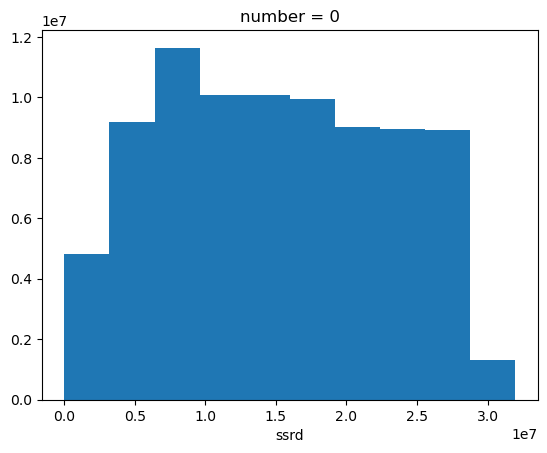

In [16]:
import xarray as xr

ds = xr.open_zarr("/mnt/CEPH_PROJECTS/InterTwin/Climate_Downscaling/EMO1_DOWNSCALING/stage_1/v0_2/SEAS5_v0_2_JANUARY_2022.zarr")

ds.ssrd.isel(number=0).plot()